## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

In [2]:
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebo

import helpers.htutorial as ut
import L08_04_07_metalearners_utils as mtl

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)
hnotebo.set_logger_to_print(_LOG)
hnotebo.set_all_loggers_to_print()

pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 3a71c0a7bf16 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


In [3]:
import warnings

import helpers.hmodule as hmodule
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
)
logging.getLogger("lightgbm").setLevel(logging.ERROR)

hmodule.install_module_if_not_present(
    ["lightgbm", "fklearn"],
    use_activate=True,
    use_sudo=False,
    venv_path="/opt/venv",
)

Module 'lightgbm' is already installed.
Module 'fklearn' is already installed.


# Load data

In [4]:
dir_name = "L08_data"
#!ls $dir_name

out_dir_name = "figures/"

In [5]:
data_biased = pd.read_csv(f"{dir_name}/email_obs_data.csv")
print("# data_biased")
print("num_rows=", len(data_biased))
display(data_biased.head())

data_rnd = pd.read_csv(f"{dir_name}/email_rnd_data.csv")
print("# data_rnd")
print("num_rows=", len(data_rnd))
display(data_rnd.head())

# data_biased
num_rows= 300000


,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,34.38,32.0,0.0,18.05,0,0,1,1,1,...,3,0,1,0,1,2,2,0,1,1
1,0,183.14,23.0,1.0,182.97,0,0,0,1,0,...,1,1,0,0,0,2,2,1,2,1
2,0,54.26,29.0,0.0,29.57,0,0,0,1,4,...,3,0,0,0,3,0,0,0,1,4
3,1,1409.71,44.0,0.0,142.15,1,2,0,1,0,...,1,0,1,1,1,3,0,1,0,5
4,0,120.16,30.0,0.0,132.11,0,1,1,0,1,...,1,2,1,1,2,3,0,0,2,5


# data_rnd
num_rows= 10000


,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,244.26,61.0,1.0,21.84,0,2,2,0,2,...,1,0,0,3,1,0,1,0,0,2
1,0,29.67,36.0,1.0,107.40,0,2,0,2,0,...,1,1,1,2,1,2,1,0,2,2
2,0,11.73,64.0,0.0,59.81,0,1,0,0,0,...,2,0,0,3,0,1,0,1,0,1
3,0,41.41,74.0,0.0,62.98,0,1,0,0,3,...,1,0,2,2,1,1,0,4,1,0
4,0,447.89,59.0,0.0,72.56,0,1,1,3,2,...,5,0,0,1,0,0,1,1,2,1


In [6]:
hdbg.dassert_eq(data_biased.columns.tolist(), data_rnd.columns.tolist())

In [7]:
y = "next_mnth_pv"
T = "mkt_email"
X = list(data_rnd.drop(columns=[y, T]).columns)

train, test = data_biased, data_rnd

In [8]:
display(train[[T, y]].head())

,mkt_email,next_mnth_pv
0,0,34.38
1,0,183.14
2,0,54.26
3,1,1409.71
4,0,120.16


# T-Learner

In [9]:
np.random.seed(123)

m0 = LGBMRegressor()
m1 = LGBMRegressor()

m0.fit(train.query(f"{T}==0")[X].values, train.query(f"{T}==0")[y].values)
m1.fit(train.query(f"{T}==1")[X].values, train.query(f"{T}==1")[y].values);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 146759, number of used features: 25
[LightGBM] [Info] Start training from score 88.249324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 153241, number of used features: 25
[LightGBM] [Info] Start training from score 1596.224063


In [10]:
m0

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
t_learner_cate_test = test.assign(
    cate=m1.predict(test[X].values) - m0.predict(test[X].values)
)

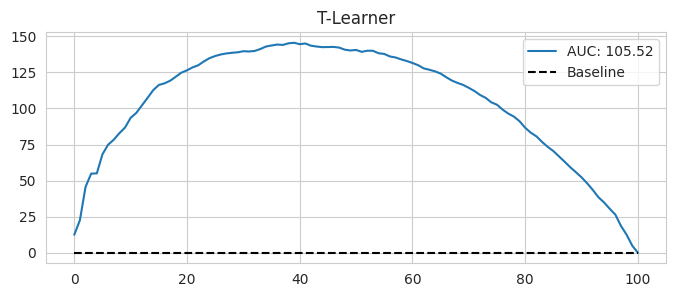

In [12]:
_ = mtl.plot_gain_curve_analysis(t_learner_cate_test, T, y, title="T-Learner")

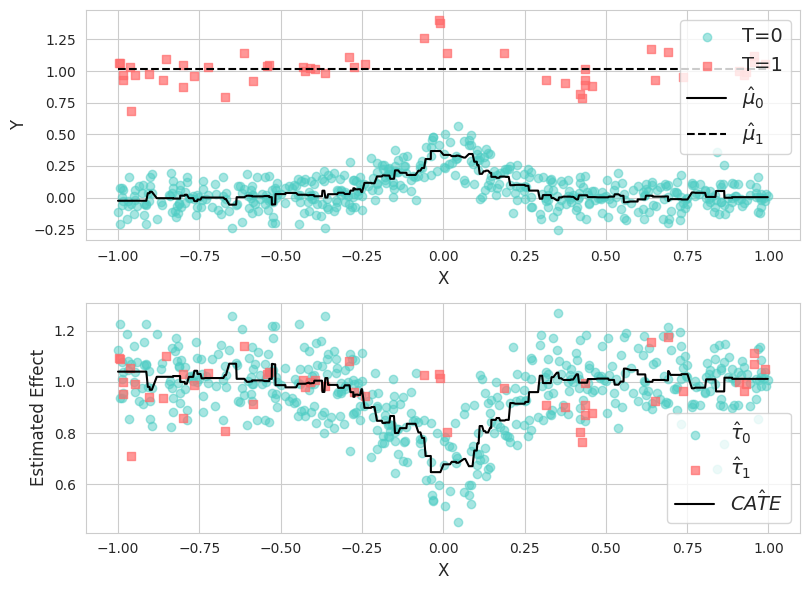

In [13]:
# Generate synthetic data with treatment heterogeneity.
df = mtl.generate_synthetic_treatment_data(n0=500, n1=50, seed=123)

# Fit separate outcome models for control and treatment groups.
m0, m1, m0_hat, m1_hat = mtl.fit_tlearner_models(df, min_child_samples=25)

# Visualize outcome models and heterogeneous treatment effects.
mtl.plot_tlearner_treatment_effect_analysis(df, m0, m1, m0_hat, m1_hat)

# X-Learner

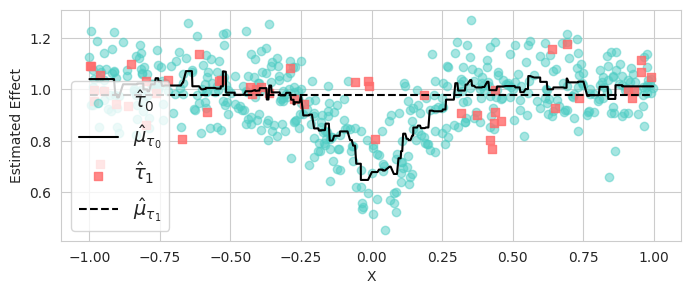

In [14]:
# Calculate heterogeneous treatment effects.
# np.random.seed(1)

tau_0, tau_1 = mtl.calculate_xlearner_heterogeneous_treatment_effects(df, m0, m1)

# Fit X-Learner models.

mu_tau0, mu_tau1, mu_tau0_hat, mu_tau1_hat = mtl.fit_xlearner_models(
    df, tau_0, tau_1, min_child_samples=25
)
# Plot heterogeneous treatment effect estimates.
mtl.plot_xlearner_effect_estimates(df, tau_0, tau_1, mu_tau0_hat, mu_tau1_hat)

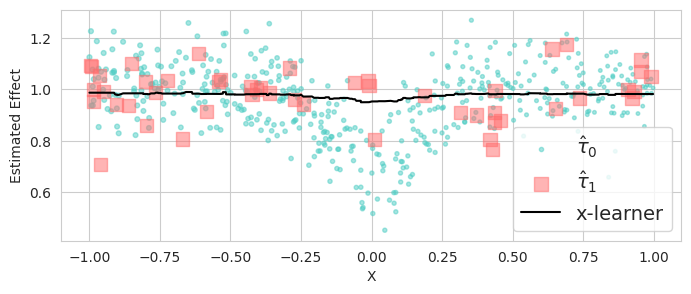

In [15]:
# Plot X-Learner CATE with propensity score weighting.
mtl.plot_xlearner_with_propensity_scores(df, mu_tau0, mu_tau1, tau_0, tau_1)

In [16]:
# Fit propensity score model and first-stage outcome models with inverse
# probability weighting.
ps_model, m0, m1 = mtl.fit_propensity_score_and_weighted_outcome_models(
    train, X, T, y
)

In [17]:
# Fit second-stage models on residual treatment effects.
m_tau_0, m_tau_1 = mtl.fit_xlearner_second_stage_models(train, X, T, y, m0, m1)

In [18]:
# Estimate the CATE using propensity-score-weighted X-Learner effects.
x_cate_test = mtl.estimate_xlearner_cate(test, X, ps_model, m_tau_0, m_tau_1)

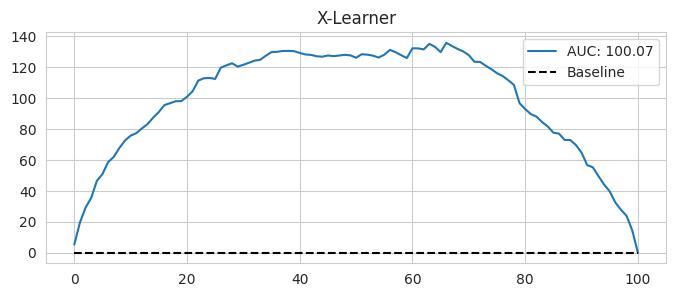

In [19]:
_ = mtl.plot_gain_curve_analysis(x_cate_test, T, y, title="X-Learner")

# S-Learner

In [20]:
data_cont = pd.read_csv(f"{dir_name}/discount_data.csv")
print(data_cont.shape[0])
data_cont.head()

7679


,rest_id,day,month,weekday,weekend,is_holiday,is_dec,is_nov,competitors_price,discounts,sales
0,0,2016-01-01,1,4,False,True,False,False,2.88,0,79.0
1,0,2016-01-02,1,5,True,False,False,False,2.64,0,57.0
2,0,2016-01-03,1,6,True,False,False,False,2.08,5,294.0
3,0,2016-01-04,1,0,False,False,False,False,3.37,15,676.5
4,0,2016-01-05,1,1,False,False,False,False,3.79,0,66.0


In [21]:
train = data_cont.query("day<'2018-01-01'")
print(train.shape[0])
test = data_cont.query("day>='2018-01-01'")
print(test.shape[0])

5117
2562


In [22]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

s_learner = mtl.fit_slearner_model(train, X, T, y)

In [23]:
test_cf = mtl.generate_slearner_counterfactual_predictions(
    test, X, T, y, s_learner, np.array([0, 10, 20, 30, 40])
)

test_cf.head(8)

,rest_id,day,month,weekday,weekend,is_holiday,is_dec,is_nov,competitors_price,sales,key,discounts,sales_hat
0,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,0,67.957972
1,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,10,444.245941
2,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,20,793.045769
3,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,30,1279.640793
4,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,40,1512.630767
5,0,2018-01-02,1,1,False,False,False,False,3.06,541.0,1,0,65.672080
6,0,2018-01-02,1,1,False,False,False,False,3.06,541.0,1,10,495.669220
7,0,2018-01-02,1,1,False,False,False,False,3.06,541.0,1,20,1015.401471


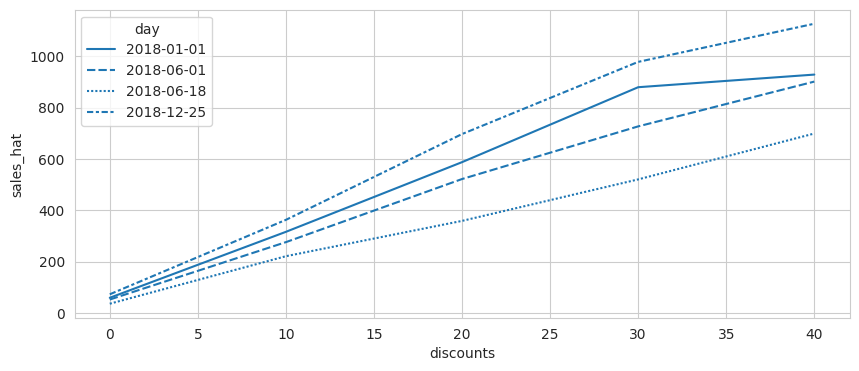

In [24]:
days = ["2018-12-25", "2018-01-01", "2018-06-01", "2018-06-18"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=test_cf.query("day.isin(@days)").query("rest_id==2"),
    y="sales_hat",
    x="discounts",
    style="day",
);

In [25]:
test_s_learner_pred = mtl.estimate_slearner_cate(test_cf, test, T, y)

test_s_learner_pred.head()

,competitors_price,day,is_dec,is_holiday,is_nov,month,rest_id,sales,weekday,weekend,discounts,cate
0,4.92,2018-01-01,False,True,False,1,0,251.5,0,False,5,37.247404
1,3.06,2018-01-02,False,False,False,1,0,541.0,1,False,10,40.269854
2,4.61,2018-01-03,False,False,False,1,0,431.0,2,False,10,37.412988
3,4.84,2018-01-04,False,False,False,1,0,760.0,3,False,20,38.436815
4,6.29,2018-01-05,False,False,False,1,0,78.0,4,False,0,31.428603


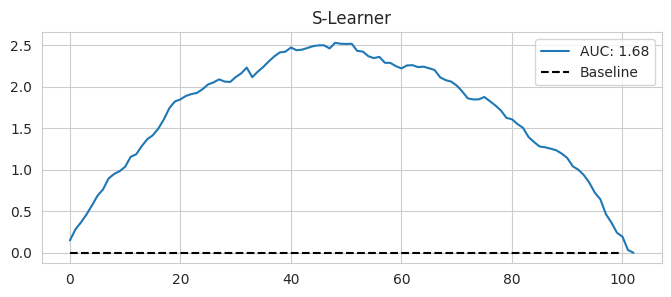

In [26]:
_ = mtl.plot_gain_curve_analysis(test_s_learner_pred, T, y, title="S-Learner")

# Double ML / R-Learner

In [27]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

# Fit debiasing and denoising models.
debias_m, denoise_m = mtl.fit_rlearner_models(train, X, T, y)

In [28]:
# Fit R-Learner CATE model.
cate_model, t_res, y_res = mtl.fit_rlearner_cate_model(
    train, X, T, y, debias_m, denoise_m
)

In [29]:
# Check coefficients via OLS regression (optional diagnostic).
import statsmodels.api as sm

sm.OLS(y_res, t_res).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
discounts,31.4634,0.151,209.017,0.000,31.168,31.759


In [30]:
# Estimate CATE on test set.
test_r_learner_pred = mtl.estimate_rlearner_cate(test, X, cate_model)

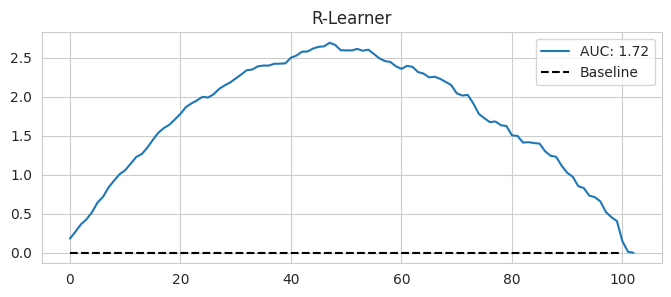

In [31]:
# Plot gain curve analysis for R-Learner.
_ = mtl.plot_gain_curve_analysis(test_r_learner_pred, T, y, title="R-Learner")